In [ ]:
# cloning GitHub Repo
!git clone https://github.com/chase-kusterer/DAT-7466.git

# changing directory
import os
repo_name = '/content/DAT-7466/' 
os.chdir(repo_name)

# checking results
print(f"Current working directory changed to: {os.getcwd()}")

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<br>
<h1>Linear Relationships</h1>
<em>Introduction to Python | In-Class Script</em><br><br>

Written by Chase Kusterer - Faculty of Analytics <br>
Hult International Business School <br>
<a href="https://github.com/chase-kusterer">https://github.com/chase-kusterer</a> <br><br><br><br><br>
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<br>
Throughout this session, we will focus on understanding how each feature in the dataset affects the price of a diamond engagement ring. In other words, we will be exploring the relationships between price and all of the features in the dataset (including non-numeric features). Before moving forward, however, it is important to acknowledge that correlation does not imply causation. If this concept is new to you, please take a moment to read <a href="https://hbr.org/2015/06/beware-spurious-correlations">this article</a> from Harvard Business Review.
<br><br><br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>

~~~
Some people feel the rain. Others just get wet.
    - Bob Marley
~~~


<br>
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<br>
<h4>S14.1.1) Complete the code to import the diamonds dataset with proper data types.</h4>
Use the <em>diamonds</em> sheet of the <em>diamonds.xlsx</em> Excel file.
<h2>Part I: Linear Correlation</h2>

In [1]:
## Session 14.1.1 ##

# importing packages
import pandas as pd             # data science essentials
import matplotlib.pyplot as plt # NEW: data visualization essentials
import seaborn as sns           # NEW: enhanced data visualization


# suppressing user warnings
import warnings # warnings
warnings.simplefilter(action='ignore', category=UserWarning)

# specifying a file name
file = 'diamonds.xlsx'


# converting data types with a dictionary
data_types = {"channel" : str,
              "store"   : str}


# reading the file into Python through pandas
diamonds = pd.read_excel(io         = file      ,
                         sheet_name = 'diamonds',
                         header     = 0         ,
                         dtype      = data_types)


# outputting the first 5 rows of the dataset
diamonds.head(n = 5)

,Obs,carat,color,clarity,cut,channel,store,price
0,1,0.32,3,7,0,0,7,1375
1,2,0.35,5,7,1,0,7,1680
2,3,0.40,4,7,1,0,7,2245
3,4,0.59,5,7,0,0,3,2495
4,5,0.72,7,8,0,0,8,2699


<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>

<h4>S14.1.2) Complete the code to generate (Pearson) correlation coefficients for the <em>diamonds</em> dataset. Round your results to two decimal places.</h4>

In [3]:
help(diamonds.corr)

Help on method corr in module pandas.core.frame:

corr(method: 'CorrelationMethod' = 'pearson', min_periods: 'int' = 1, numeric_only: 'bool' = False) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Compute pairwise correlation of columns, excluding NA/null values.

    Parameters
    ----------
    method : {'pearson', 'kendall', 'spearman'} or callable
        Method of correlation:

        * pearson : standard correlation coefficient
        * kendall : Kendall Tau correlation coefficient
        * spearman : Spearman rank correlation
        * callable: callable with input two 1d ndarrays
            and returning a float. Note that the returned matrix from corr
            will have 1 along the diagonals and will be symmetric
            regardless of the callable's behavior.
    min_periods : int, optional
        Minimum number of observations required per pair of columns
        to have a valid result. Currently only available for Pearson
        and Spearman 

In [5]:
## Session 14.1.2 ##

# linear (Pearson) correlation
diamonds.iloc[ : , 1: ].corr(method = 'pearson', numeric_only = True).round(decimals = 2)

,carat,color,clarity,cut,price
carat,1.00,0.22,0.05,-0.24,0.88
color,0.22,1.00,-0.06,-0.10,-0.04
clarity,0.05,-0.06,1.00,-0.09,-0.10
cut,-0.24,-0.10,-0.09,1.00,-0.13
price,0.88,-0.04,-0.10,-0.13,1.00


In [12]:
## Session 14.1.2 ##

# linear (Pearson) correlation
diamonds[  diamonds.loc[ : , 'carat'] >= 1.5  ].iloc[ : , 1: ].corr(method = 'pearson', numeric_only = True).round(decimals = 2)

,carat,color,clarity,cut,price
carat,1.00,-0.01,-0.01,-0.23,0.60
color,-0.01,1.00,-0.17,-0.07,-0.56
clarity,-0.01,-0.17,1.00,0.04,-0.31
cut,-0.23,-0.07,0.04,1.00,-0.10
price,0.60,-0.56,-0.31,-0.10,1.00


<br><hr style="height:.9px;border-width:0;color:gray;background-color:gray"><br>

We can save this as an object as a DataFrame and then turn it into a heatmap.
<br><br>
<h4>S14.1.3) Complete the code below to:</h4><br>
&#8195;&#8195;i) store the correlation table as an object<br>
&#8195;&#8195;ii) instantiate a heatmap from the stored correlation table

In [17]:
help(sns.heatmap)

Help on function heatmap in module seaborn.matrix:

heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)
    Plot rectangular data as a color-encoded matrix.

    This is an Axes-level function and will draw the heatmap into the
    currently-active Axes if none is provided to the ``ax`` argument.  Part of
    this Axes space will be taken and used to plot a colormap, unless ``cbar``
    is False or a separate Axes is provided to ``cbar_ax``.

    Parameters
    ----------
    data : rectangular dataset
        2D dataset that can be coerced into an ndarray. If a Pandas DataFrame
        is provided, the index/column information will be used to label the
        columns and rows.
    vmin, vmax : floats, optional
        Values to anchor the colormap, otherwise they are

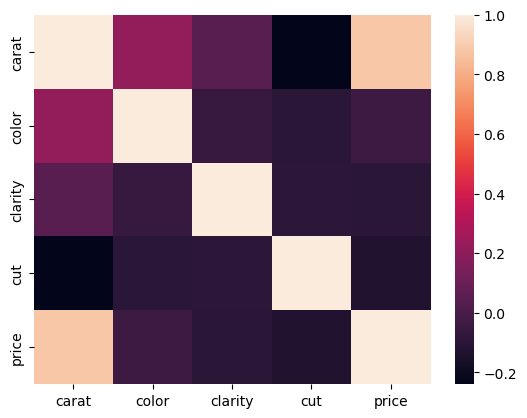

In [19]:
## Session 14.1.3 ##

# converting correlation matrix into a DataFrame
diamonds_corr = diamonds.iloc[ : , 1: ].corr(method = 'pearson',
                                             numeric_only = True).round(decimals = 2)

# instantiating a heatmap
sns.heatmap(data = diamonds_corr)


# displaying the plot
plt.show(block = True)

<br><hr style="height:.9px;border-width:0;color:gray;background-color:gray"><br>
Let's spice up the heatmap.

<br>

~~~
         -_
         `-;-_   ,--.__
            `-;-/. ,/\-`.
            _//"\\  '/  |
           /'-   \\ `;\-|    <-- chili pepper
         ,'  ;/   \\  \|;
       ./'  ;'     \\  \(
     ,-" _;'        \\  `
  ,-'_;-"            \
   "'
~~~

<br>

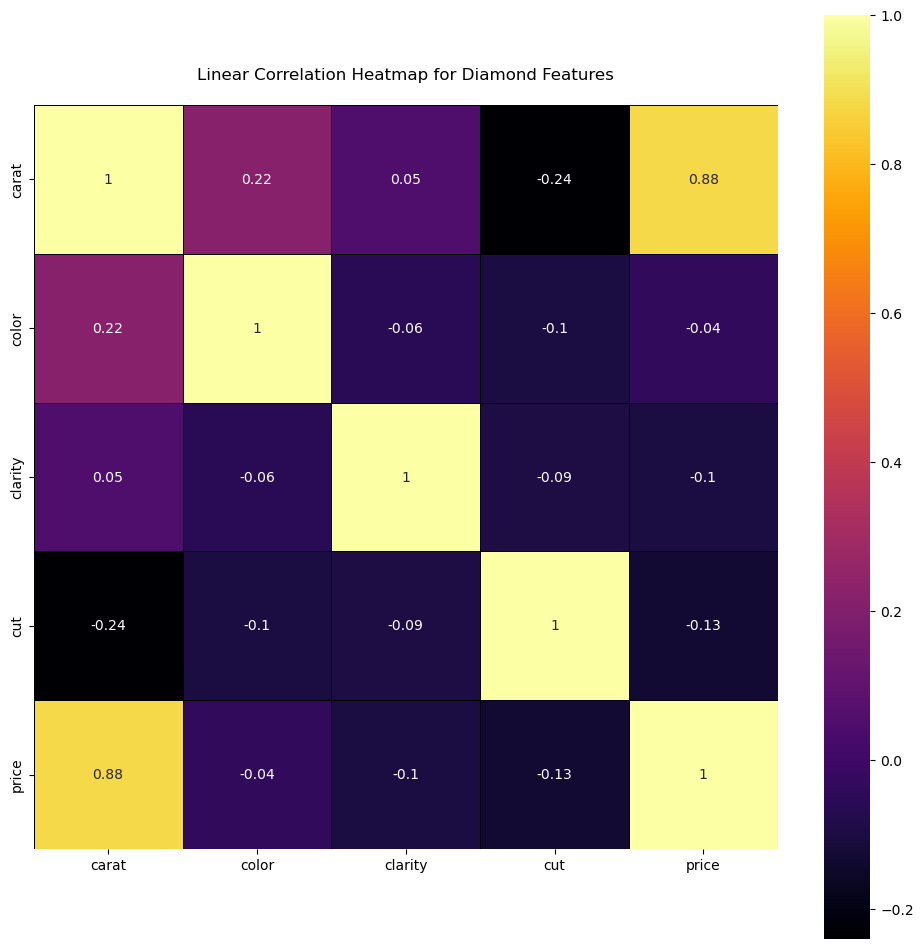

In [20]:
## Session 14.1.4 ##

# specifying plot size (making it bigger)
fig, ax = plt.subplots( figsize = (12 , 12) )


# developing a spicy heatmap
sns.heatmap(data       = diamonds_corr, # the correlation matrix
            cmap       = 'inferno'    , # changing to SPICY colors
            square     = True         , # tightening the layout
            annot      = True         , # should there be numbers in the heatmap
            linecolor  = 'black'      , # lines between boxes
            linewidths = 0.5          ) # how thick should the lines be?


# title and displaying the plot
plt.title(label = """
Linear Correlation Heatmap for Diamond Features
""")


# showing the finished product
plt.show(block = True)

<br><hr style="height:.9px;border-width:0;color:gray;background-color:gray"><br>
That was too spicy! Let's cool things down a bit in our next plot.

<br>

~~~
            .-~~\
           /     \ _
           ~x   .-~_)_
             ~x".-~   ~-.
         _   ( /         \   _
         ||   T  o  o     Y  ||       <--- snow person
       ==;l   l   <       !  |;==
          \\   \  .__/   /  //
           \\ ,r"-,___.-'r.//
            }^ \.( )   _.'//.
           /    }~Xi--~  //  \
          Y    Y I\ \    "    Y
          |    | |o\ \        |
          |    l_l  Y T       |  
          l      "o l_j       !
           \                 /
    ___,.---^.     o       .^---.._____
"~~~          "           ~            ~~~"

~~~

<br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>

<h4>S14.1.5) Complete the code to generate a heatmap with the <em>Blues</em> color scheme.</h4>

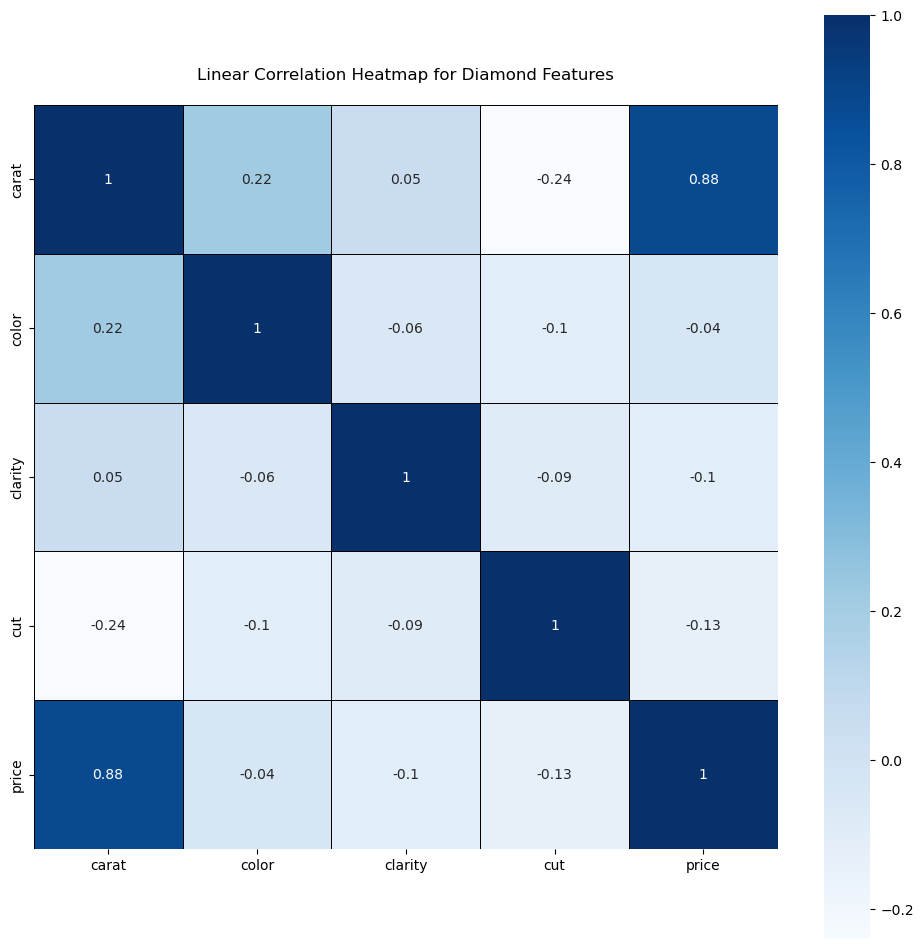

In [21]:
## Session 14.1.5 ##

# specifying plot size (making it bigger)
fig, ax = plt.subplots( figsize = (12 , 12) )


# developing a freezing cold heatmap
sns.heatmap(data       = diamonds_corr, # the correlation matrix
            cmap       = 'Blues'      , # changing to COOL colors
            square     = True         , # tightening the layout
            annot      = True         , # should there be numbers in the heatmap
            linecolor  = 'black'      , # lines between boxes
            linewidths = 0.5          ) # how thick should the lines be?


# title and displaying the plot
plt.title(label = """
Linear Correlation Heatmap for Diamond Features
""")


# rendering the visualization
plt.show(block = True)

<br><hr style="height:.9px;border-width:0;color:gray;background-color:gray"><br>
The heatmap looks freezing now! Let's change the color scheme to a mix between hot and cold.
<br><br>

~~~
                                 .''.
       .''.             *''*    :_\/_:     . 
      :_\/_:   .    .:.*_\/_*   : /\ :  .'.:.'.
  .''.: /\ : _\(/_  ':'* /\ *  : '..'.  -=:o:=-
 :_\/_:'.:::. /)\*''*  .|.* '.\'/.'_\(/_'.':'.'
 : /\ : :::::  '*_\/_* | |  -= o =- /)\    '  *
  '..'  ':::'   * /\ * |'|  .'/.\'.  '._____
      *        __*..* |  |     :      |.   |' .---"|
       _*   .-'   '-. |  |     .--'|  ||   | _|    |
    .-'|  _.|  |    ||   '-__  |   |  |    ||      |
    |' | |.    |    ||       | |   |  |    ||      |
 ___|  '-'     '    ""       '-'   '-.'    '`      |____


~~~


<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>

<h4>S14.1.6) Complete the code to generate a heatmap with the <em>coolwarm</em> color scheme.</h4>

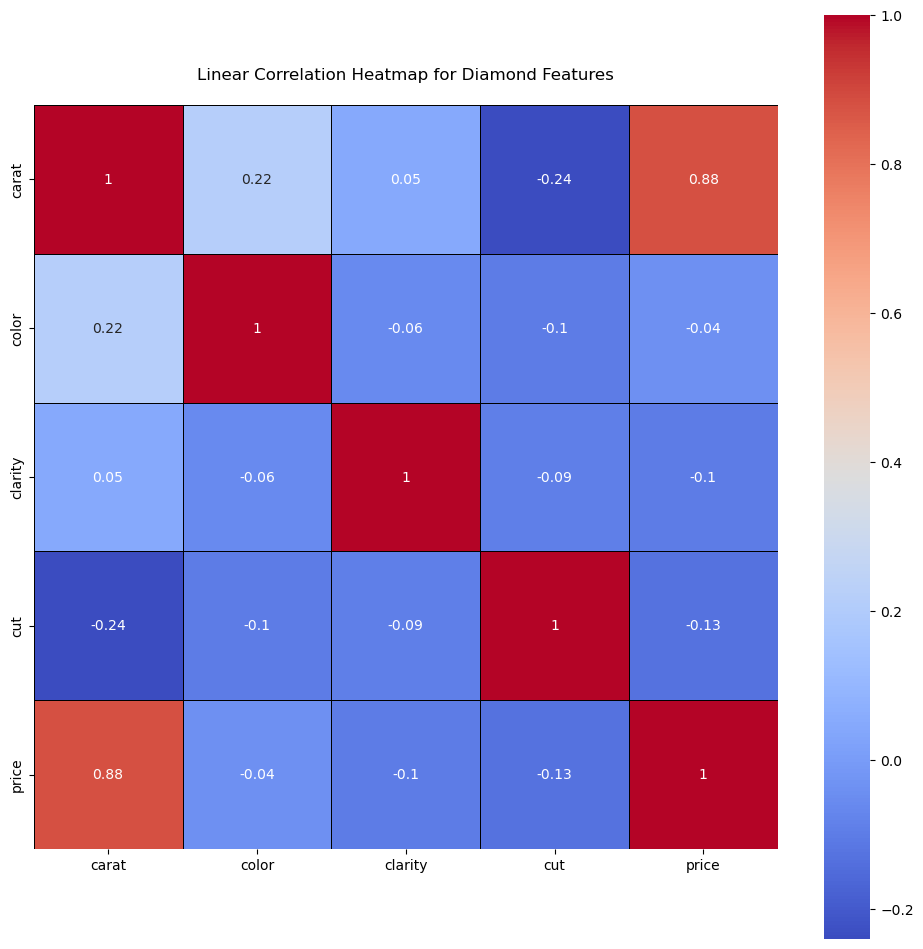

In [22]:
## Session 14.1.6 ##

# specifying plot size (making it bigger)
fig, ax = plt.subplots( figsize = (12 , 12) )


# developing a coolwarm heatmap
sns.heatmap(data       = diamonds_corr, # the correlation matrix
            cmap       = 'coolwarm'   , # changing to MEDIUM colors
            square     = True         , # tightening the layout
            annot      = True         , # should there be numbers in the heatmap
            linecolor  = 'black'      , # lines between boxes
            linewidths = 0.5          ) # how thick should the lines be?


# title and displaying the plot
plt.title(label = """
Linear Correlation Heatmap for Diamond Features
""")


# visualizing the data
plt.show(block = True)

<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>
<h2>Part II: Scatter and Linear Model Plots</h2><br>
Scatter plots are an excellent tool to analyze the relationship between two variables. Linear model plots are an enhanced version of a scatter plot that includes a trend line based on the <strong>square of the correlation coefficient</strong> between the variables being plotted. The square of the correlation coefficient is more formally known as <strong>R-Squared</strong>.
<br><br>
The code below has been developed to display a scatter plot between <em>carat</em> and <em>price</em>.

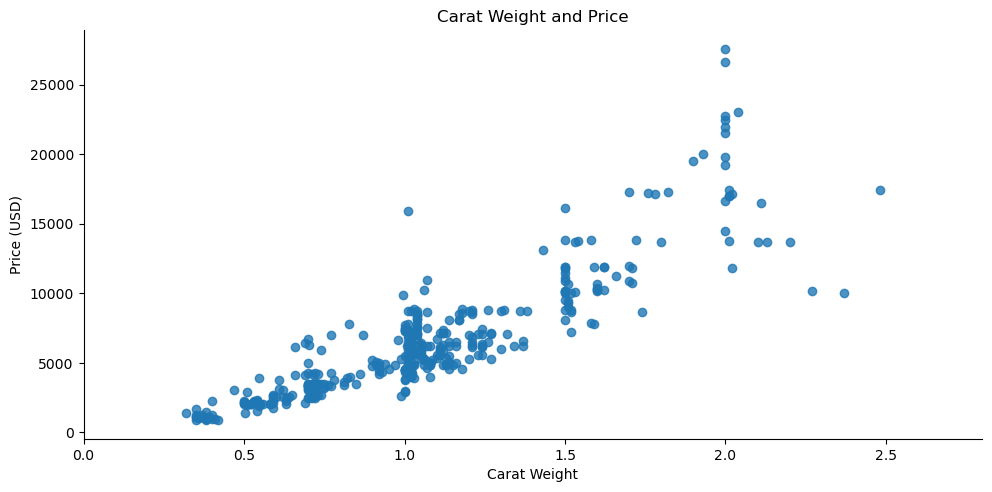

In [23]:
## Session 14.2.1 ##

# instantiating a scatter plot for carat and price
sns.lmplot(x          = 'carat' , # x-axis feature
           y          = 'price' , # y-axis feature
           hue        = None    , # categorical data for subsets
           scatter    = True    , # renders a scatter plot
           fit_reg    = False   , # renders a regression line
           aspect     = 2       , # aspect ratio for plot
           data       = diamonds) # DataFrame where features exist


# formatting and displaying the plot
plt.title       (label  = 'Carat Weight and Price')
plt.xlabel      (xlabel = 'Carat Weight'          )
plt.ylabel      (ylabel = 'Price (USD)'           )
plt.xlim        (left   = 0, right = 2.8          )
plt.tight_layout(pad    = 1.0                     )
plt.show        (block  = True                    )

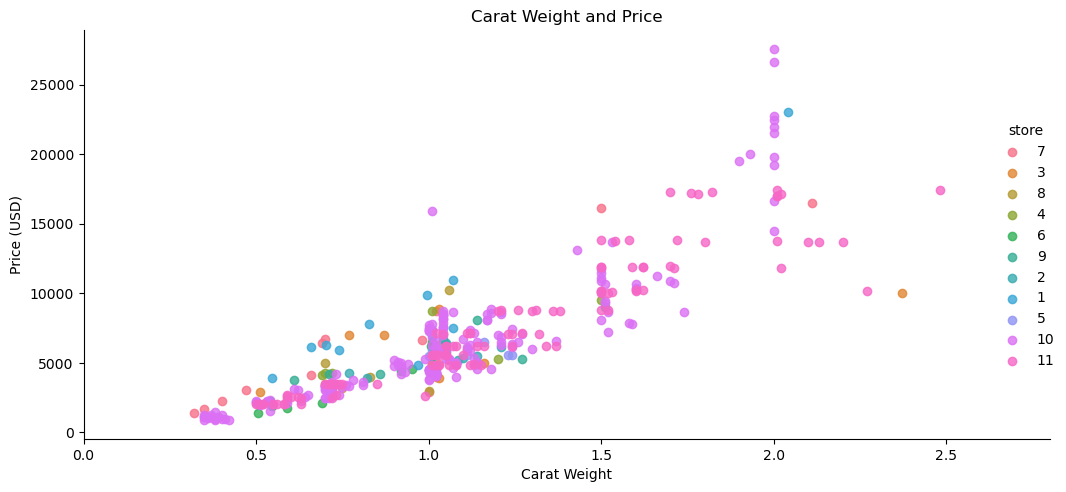

In [28]:
## Session 14.2.1 ##

# instantiating a scatter plot for carat and price
sns.lmplot(x          = 'carat' , # x-axis feature
           y          = 'price' , # y-axis feature
           hue        = 'store'    , # categorical data for subsets
           scatter    = True    , # renders a scatter plot
           fit_reg    = False   , # renders a regression line
           aspect     = 2       , # aspect ratio for plot
           data       = diamonds) # DataFrame where features exist

#plt.axvline(1.0, color = 'purple')
#plt.axhline(5795, color = 'purple')

# formatting and displaying the plot
plt.title       (label  = 'Carat Weight and Price')
plt.xlabel      (xlabel = 'Carat Weight'          )
plt.ylabel      (ylabel = 'Price (USD)'           )
plt.xlim        (left   = 0, right = 2.8          )
plt.tight_layout(pad    = 1.0                     )
plt.show        (block  = True                    )

<hr style="height:.9px;border-width:0;color:gray;background-color:gray"><br>
<h4>S14.2.2) Change the value of the <em>fit_reg</em> argument to True.</h4>

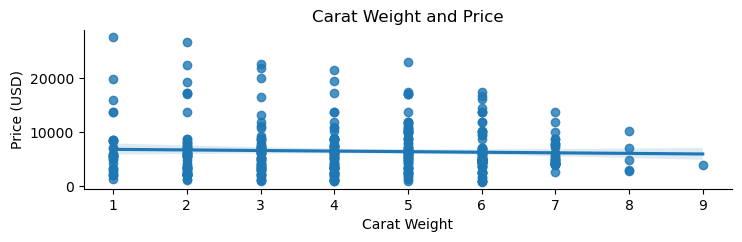

In [30]:
## Session 14.2.2 ##

# instantiating an lmplot for carat and price
sns.lmplot(x       = 'color' , # x-axis feature
           y       = 'price' , # y-axis feature
           hue     = None    , # categorical data for subsets
           scatter = True    , # renders a scatter plot
           fit_reg = True    , # renders a regression line
           aspect  = 2       , # aspect ratio for plot
           data    = diamonds) # DataFrame where features exist


# formatting and displaying the visualization
plt.title       (label  = 'Carat Weight and Price')
plt.xlabel      (xlabel = 'Carat Weight'          )
plt.ylabel      (ylabel = 'Price (USD)'           )
#plt.xlim        (left   = 0, right = 2.8          )
plt.tight_layout(pad    = 10.0                    )
plt.show        (block  = True                    )

<hr style="height:.9px;border-width:0;color:gray;background-color:gray"><br>

According to <a href="miller_mds_two_months_salary_case.pdf">the documentation on the dataset</a>, "diamonds are sized in one-quarter increments". However, it does not appear that the trend between price and carat weight changes with each 0.25 increment. What the documentation likely meant was that when a diamond is sold to a customer, it is replaced with a new one that has a relatively similar carat weight. It does look, however, that the trend becomes more steep as carat weight increases beyond 1.50. Also, there appears to be a downward-sloping trend after carat weight surpasses 2.00 (although we do not have many observations with carat weights above this threshold).
<br><br>
Let's develop vertical axis lines at half carat increments and store this as a categorical variable. This has been done in the code cell below, as well as revisualizing the scatter plot.

/var/folders/p2/ln281wn16mg7xhwqhxdxlfv80000gn/T/ipykernel_71583/4258563815.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.0, 0.5)' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  diamonds.loc[index, 'Carat Size'] = '[0.0, 0.5)'


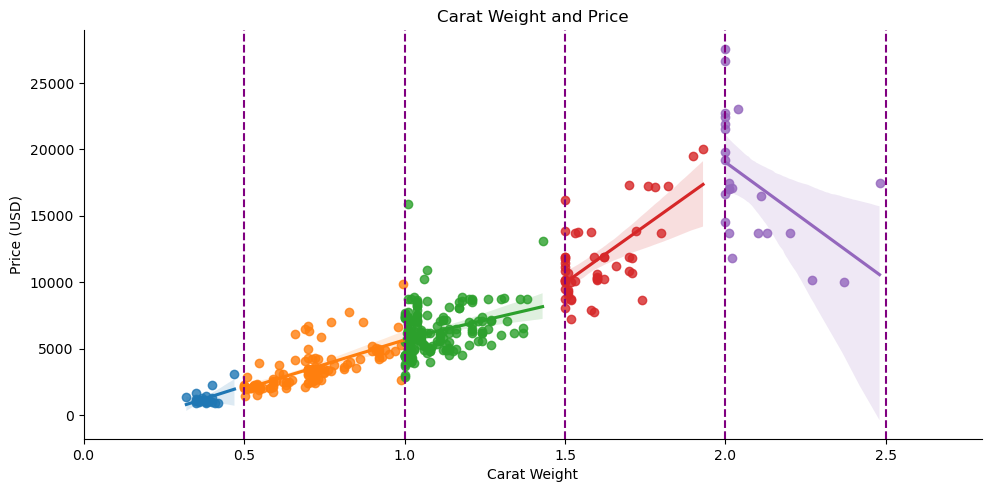

In [27]:
## Session 14.2.4 ##

# creating a dummy column in the diamonds DataFrame
diamonds['Carat Size'] = 0


# for loop with iterrows() <-- one of the most useful methods for DataFrames
for index, col in diamonds.iterrows():
    
    
    # conditionals to change the values in the new column
    if diamonds.loc[index, 'carat'] < 0.5:
        diamonds.loc[index, 'Carat Size'] = '[0.0, 0.5)'
        
        
    elif diamonds.loc[index, 'carat'] < 1.0:
        diamonds.loc[index, 'Carat Size'] = '[0.5 - 1.0)'
        
        
    elif diamonds.loc[index, 'carat'] < 1.5:
        diamonds.loc[index, 'Carat Size'] = '[1.0 - 1.5)'
        
        
    elif diamonds.loc[index, 'carat'] < 2.0:
        diamonds.loc[index, 'Carat Size'] = '[1.5 - 2.0)'
        
        
    elif diamonds.loc[index, 'carat'] >= 2.0: # this is where the bug was
        diamonds.loc[index, 'Carat Size'] = '[2.0 - inf)'
    
    
    # safety net
    else:
        diamonds.loc[index, 'Carat Size'] = 'error'


# instantiating an lmplot for carat and price
sns.lmplot(x          = 'carat'     ,  
           y          = 'price'     ,  
           hue        = 'Carat Size', # categorical data for subsets
           legend     = False       , # supressing the legend 
           scatter    = True        ,     
           fit_reg    = True        ,     
           aspect     = 2           ,        
           data       = diamonds    )


# developing vertical axis lines
value = 0.50

while value < 3.00:
    
    # making a vertical line
    plt.axvline(x = value, color = "purple", linestyle = '--')
    
    # incrementing value in one-quarter increments
    value += 0.50


# formatting and displaying the plot
plt.title       (label  = 'Carat Weight and Price')
plt.xlabel      (xlabel = 'Carat Weight'          )
plt.ylabel      (ylabel = 'Price (USD)'           )
plt.xlim        (left   = 0, right = 2.8          )
plt.tight_layout(pad    = 1.0                     )
plt.show        (block  = True                    )

<hr style="height:.9px;border-width:0;color:gray;background-color:gray"><br>
<h2> Part III: Boxplots</h2>

Boxplots can be made as easily as other plots in seaborn.

In [ ]:
help(sns.boxplot)

<br>
<h4>Build a boxplot in the code cell below with any variable(s) you like.</h4>

In [36]:
help(sns.catplot)

Help on function catplot in module seaborn.categorical:

catplot(data=None, *, x=None, y=None, hue=None, row=None, col=None, kind='strip', estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, units=None, weights=None, order=None, hue_order=None, row_order=None, col_order=None, col_wrap=None, height=5, aspect=1, log_scale=None, native_scale=False, formatter=None, orient=None, color=None, palette=None, hue_norm=None, legend='auto', legend_out=True, sharex=True, sharey=True, margin_titles=False, facet_kws=None, ci=<deprecated>, **kwargs)
    Figure-level interface for drawing categorical plots onto a FacetGrid.

    This function provides access to several axes-level functions that
    show the relationship between a numerical and one or more categorical
    variables using one of several visual representations. The `kind`
    parameter selects the underlying axes-level function to use.

    Categorical scatterplots:

    - :func:`stripplot` (with `kind="strip"`; the default)
  

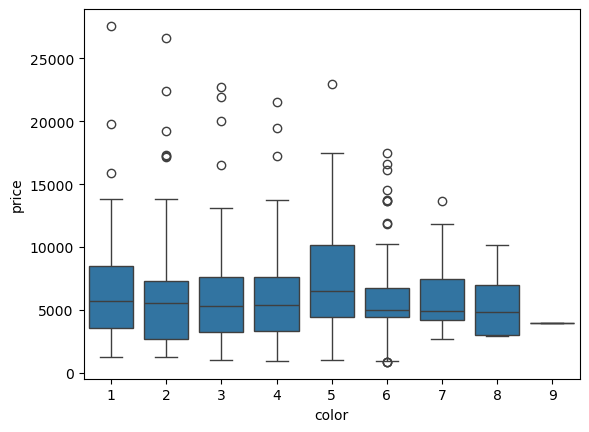

In [34]:
# have fun!
sns.boxplot(data = diamonds,
            x    = 'color',
            y    = 'price',
           # hue = 'cut'
           )


plt.show()

<br><hr style="height:.9px;border-width:0;color:gray;background-color:gray"><br>

~~~
                       ________
               o      |   __   |
                 \_ O |  |__|  |
              ____/ \ |___WW___|
              __/   /     ||
                          ||
                          ||
           _______________||________________


   _____ _                   _____              _    _ 
  / ____| |                 |  __ \            | |  | |
 | (___ | | __ _ _ __ ___   | |  | |_   _ _ __ | | _| |
  \___ \| |/ _` | '_ ` _ \  | |  | | | | | '_ \| |/ / |
  ____) | | (_| | | | | | | | |__| | |_| | | | |   <|_|
 |_____/|_|\__,_|_| |_| |_| |_____/ \__,_|_| |_|_|\_(_)
                                                       
                                                       


~~~

<br>

<br>